[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_6177/146775877.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


    name  cluster
0    bam        0
1   niem        3
2    aem        3
3  yaeks        3
4  jeeks        3
5    aez        2
6    sax        3
7   eert        3
8    wuc        3
9    yac        3

Cluster counts:
cluster
3    26
1     2
0     1
2     1
Name: count, dtype: int64


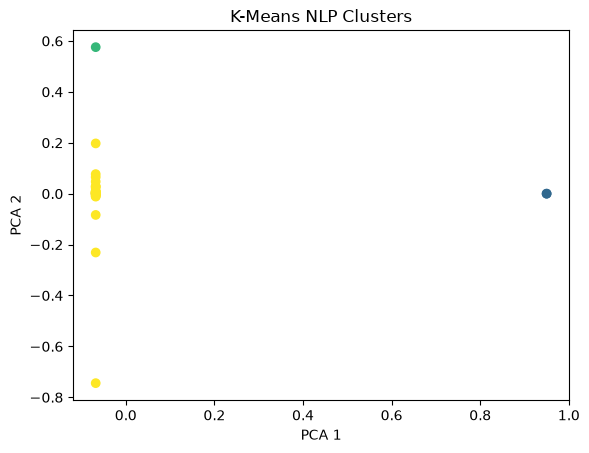

In [1]:
# Install if needed:
# !pip install pandas scikit-learn nltk matplotlib

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

nltk.download('stopwords')

# 1. Load dataset
df = pd.read_csv("dnd-dataframe.csv")

# 2. Select text column
text_col = df.select_dtypes(include="object").columns[0]
df[text_col] = df[text_col].fillna("")

# 3. NLP cleaning
stop = set(stopwords.words("english"))

def clean(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    return " ".join(w for w in text.split() if w not in stop)

df["clean_text"] = df[text_col].apply(clean)

# 4. TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df["clean_text"])

# 5. K-Means
k = 4
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 6. Show results
print(df[[text_col, "cluster"]].head(10))
print("\nCluster counts:")
print(df["cluster"].value_counts())

# 7. Visualise
pca = PCA(n_components=2)
X2 = pca.fit_transform(X.toarray())

plt.scatter(X2[:,0], X2[:,1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means NLP Clusters")
plt.show()

# 8. Save results
df.to_csv("dnd-clustered.csv", index=False)